In [175]:
import numpy as np
import pandas as pd

In [176]:
# For file handling
from pathlib import Path
Project_root  = Path.cwd().parent

Data_path = Project_root / "Data" / "processed" / "Gurgaon_merged.csv"

df = pd.read_csv(Data_path)
pd.set_option('display.max_colwidth', 50)
df.head()

,Unnamed: 0,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,not_available,4.0,West,1 to 5 Year Old,"['Chintapurni Mandir', 'State bank ATM', 'Pear...","['3 Fan', '4 Light', '1 Wardrobe', 'No AC', 'N...","['Feng Shui / Vaastu Compliant', 'Security / F..."
1,1,flat,apna enclave,sector 5,0.50,7692.0,650.0,Carpet area: 650 (60.39 sq.m.),2,2,1,not_available,1.0,West,10+ Year Old,"['Chintapurni Mandir', 'Sheetla Mata Mandir', ...","['3 Wardrobe', '4 Fan', '1 Exhaust Fan', '1 Ge...","['Security / Fire Alarm', 'Maintenance Staff',..."
2,2,flat,tulsiani easy in homes,sector 48,0.40,6722.0,595.0,Carpet area: 595 (55.28 sq.m.),2,2,3,not_available,12.0,NaN,0 to 1 Year Old,"['Huda City Metro', 'Golf Course extn road', '...",NaN,"['Power Back-up', 'Feng Shui / Vaastu Complian..."
3,3,flat,smart world orchard,sector 61,1.47,12250.0,1200.0,Carpet area: 1200 (111.48 sq.m.),2,2,2,study room,2.0,NaN,Dec 2023,"['Sector 55-56 Metro station', 'Bestech Centra...",NaN,"['Security / Fire Alarm', 'Private Garden / Te..."
4,4,flat,parkwood westend,sector 92,0.70,5204.0,1345.0,Super Built up area 1345(124.95 sq.m.),2,2,3,study room,5.0,NaN,Under Construction,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. ...",[],NaN


In [177]:
# Checking the null values and data types of the columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3961 entries, 0 to 3960
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       3961 non-null   int64  
 1   property_type    3961 non-null   object 
 2   society          3391 non-null   object 
 3   sector           3961 non-null   object 
 4   price            3941 non-null   float64
 5   price_per_sqft   3941 non-null   float64
 6   area             3941 non-null   float64
 7   areaWithType     3961 non-null   object 
 8   bedRoom          3961 non-null   int64  
 9   bathroom         3961 non-null   int64  
 10  balcony          3961 non-null   object 
 11  additionalRoom   3961 non-null   object 
 12  floorNum         2992 non-null   float64
 13  facing           2784 non-null   object 
 14  agePossession    3960 non-null   object 
 15  nearbyLocations  3754 non-null   object 
 16  furnishDetails   2929 non-null   object 
 17  features      

In [178]:
# Checking the duplicate rows in the Data Frame.
df.duplicated().sum()

np.int64(0)

In [179]:
# Checking the unique values in the areaWithType column
df.areaWithType.value_counts()

areaWithType
Plot area 360(301.01 sq.m.)                                                                                                     38
Plot area 300(250.84 sq.m.)                                                                                                     27
Plot area 200(167.23 sq.m.)                                                                                                     20
Plot area 270(225.75 sq.m.)                                                                                                     19
Plot area 502(419.74 sq.m.)                                                                                                     19
Super Built up area 1950(181.16 sq.m.)Carpet area: 1161 sq.ft. (107.86 sq.m.)                                                   17
Super Built up area 1350(125.42 sq.m.)                                                                                          17
Super Built up area 1578(146.6 sq.m.)                                 

In [180]:

df['areaWithType'].unique()

array(['Carpet area: 900 (83.61 sq.m.)', 'Carpet area: 650 (60.39 sq.m.)',
       'Carpet area: 595 (55.28 sq.m.)', ...,
       'Plot area 1800(167.23 sq.m.)Built Up area: 4800 sq.ft. (445.93 sq.m.)Carpet area: 3800 sq.ft. (353.03 sq.m.)',
       'Plot area 172(143.81 sq.m.)',
       'Plot area 1600(148.64 sq.m.)Built Up area: 1700 sq.ft. (157.94 sq.m.)Carpet area: 1650 sq.ft. (153.29 sq.m.)'],
      shape=(2443,), dtype=object)

In [181]:
# This function extracts area type from areaWithType column
import re

def get_area(text, area_type):
    match =  re.search(area_type + r'\s*:?\s*(\d+\.?\d*)', text)

    if match:
        return float(match.group(1))
    return None

In [182]:
# This function checks if the area is in sq_feet and if not then converts it to sq_ft.

def sq_ft_convert(text, area_value):
    if area_value is None:
        return None
    match = re.search(r'{}\s*\((\d+\.?\d*) sq\.m\.\)'.format(area_value), text)
    
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639 # It is the conversion ratio from sq_m to sq_ft.
    return area_value


In [183]:
# Extracting the area type and converting it to the sq_ft if needed.
df["Super_built_up_area"] = df['areaWithType'].apply(lambda x : get_area(x, "Super Built up area"))
df["Super_built_up_area"] = df.apply(lambda x : sq_ft_convert(x['areaWithType'], x['Super_built_up_area']), axis=1)

df['Carpet_area'] = df['areaWithType'].apply(lambda x : get_area(x, "Carpet area"))
df['Carpet_area'] = df.apply(lambda x : sq_ft_convert(x['areaWithType'], x['Carpet_area']), axis=1)

df['Plot_area'] = df['areaWithType'].apply(lambda x : get_area(x, "Plot area"))
df['Plot_area'] = df.apply(lambda x : sq_ft_convert(x['areaWithType'], x['Plot_area']), axis=1)

In [184]:
df['built_up_area'] = df['areaWithType'].apply(lambda x : get_area(x, "Built Up area"))
df['built_up_area'] = df.apply(lambda x : sq_ft_convert(x['areaWithType'], x['built_up_area']), axis=1)

In [185]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3961 entries, 0 to 3960
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           3961 non-null   int64  
 1   property_type        3961 non-null   object 
 2   society              3391 non-null   object 
 3   sector               3961 non-null   object 
 4   price                3941 non-null   float64
 5   price_per_sqft       3941 non-null   float64
 6   area                 3941 non-null   float64
 7   areaWithType         3961 non-null   object 
 8   bedRoom              3961 non-null   int64  
 9   bathroom             3961 non-null   int64  
 10  balcony              3961 non-null   object 
 11  additionalRoom       3961 non-null   object 
 12  floorNum             2992 non-null   float64
 13  facing               2784 non-null   object 
 14  agePossession        3960 non-null   object 
 15  nearbyLocations      3754 non-null   o

In [186]:
# Checking the rows where all the area columns are null.
df[['area','Super_built_up_area','Carpet_area','Plot_area','built_up_area']].sample(50)

,area,Super_built_up_area,Carpet_area,Plot_area,built_up_area
177,1180.0,NaN,1180.00,NaN,NaN
700,1400.0,1500.0,1400.00,NaN,1450.0
2965,1850.0,1850.0,NaN,NaN,NaN
3489,1000.0,NaN,NaN,NaN,1000.0
519,2361.0,2361.0,NaN,NaN,1950.0
1413,1480.0,1480.0,NaN,NaN,NaN
1240,1990.0,1990.0,1700.00,NaN,NaN
3817,1187.0,NaN,1187.00,NaN,NaN
451,2092.0,2092.0,NaN,NaN,NaN
3401,1800.0,NaN,NaN,200.0,NaN


In [187]:
# Checking the rows where all the area columns are null.
df[
    df['Super_built_up_area'].isna() &
    df['Carpet_area'].isna() &
    df['Plot_area'].isna() &
    df['built_up_area'].isna()
]

,Unnamed: 0,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,...,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,Super_built_up_area,Carpet_area,Plot_area,built_up_area



Super_built_up_area
count    1934.000000
mean       68.419062
std       181.847678
min         0.000000
25%         0.000000
50%         0.000000
75%         3.000000
max      1728.000000
dtype: float64

built_up_area
count      1228.000000
mean        555.387165
std        4400.644453
min           0.000000
25%           0.000000
50%         100.000000
75%         340.000000
max      137853.000000
dtype: float64

Carpet_area
count     2000.000000
mean       517.318944
std       3501.224147
min          0.000000
25%          0.000000
50%         21.000000
75%        463.500000
max      87978.000000
dtype: float64

Plot_area
count    7.500000e+02
mean     1.201532e+04
std      2.648110e+05
min      0.000000e+00
25%      1.000000e+00
50%      1.441500e+03
75%      2.528000e+03
max      7.249800e+06
dtype: float64


In [191]:
# Additional room
df["additionalRoom"].value_counts()

additionalRoom
not_available                                    1691
servant room                                      710
study room                                        251
others                                            237
pooja room                                        170
store room                                        107
study room,servant room                           100
pooja room,servant room                            84
pooja room,study room,servant room,store room      72
servant room,others                                60
pooja room,study room,servant room                 57
pooja room,study room,servant room,others          57
servant room,pooja room                            38
servant room,store room                            34
study room,others                                  30
pooja room,study room                              24
pooja room,others                                  17
pooja room,store room                              17
servant room,

In [192]:
# creating new columns for additional rooms --> study room, servant room, pooja room, store room, other etc.
new_cols = ['study room', 'servant room', 'pooja room', 'store room', 'others']

for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [193]:
df.sample(5)

,Unnamed: 0,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,...,features,Super_built_up_area,Carpet_area,Plot_area,built_up_area,study room,servant room,pooja room,store room,others
2492,2492,flat,smart world gems,sector 89,1.20,8433.0,1423.0,Built Up area: 1423 (132.2 sq.m.)Carpet area: ...,3,3,...,NaN,NaN,920.0,NaN,1423.0,0,0,0,0,0
2292,2292,flat,conscient heritage max,sector 102,2.50,11633.0,2149.0,Super Built up area 2149(199.65 sq.m.),3,4,...,"['Feng Shui / Vaastu Compliant', 'Security / F...",2149.0,NaN,NaN,NaN,1,1,0,0,0
2651,2651,flat,vatika sovereign park,sector 99,3.25,9672.0,3360.0,Super Built up area 3360(312.15 sq.m.),4,4,...,"['Security / Fire Alarm', 'Intercom Facility',...",3360.0,NaN,NaN,NaN,0,1,0,0,0
1820,1820,flat,ss the leaf,sector 85,1.58,7714.0,2048.0,Super Built up area 2408(223.71 sq.m.)Carpet a...,3,4,...,"['Centrally Air Conditioned', 'Water purifier'...",2408.0,2048.0,NaN,NaN,0,1,0,0,0
3077,3077,house,NaN,sector 82,7.00,21605.0,3240.0,Plot area 360(301.01 sq.m.),4,4,...,"['Feng Shui / Vaastu Compliant', 'Private Gard...",NaN,NaN,360.0,NaN,1,1,1,0,0


In [194]:
# agePossession

df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1705
5 to 10 Year Old       610
0 to 1 Year Old        551
undefined              358
10+ Year Old           353
Under Construction      92
Within 6 months         70
Within 3 months         26
Dec 2023                22
By 2023                 19
By 2024                 17
Dec 2024                16
Mar 2024                14
Oct 2024                 8
Jan 2024                 8
Aug 2023                 7
Dec 2025                 7
Jun 2024                 7
Aug 2024                 5
Nov 2023                 5
Sep 2023                 4
Jul 2024                 4
Oct 2023                 4
Jan 2025                 4
By 2025                  4
May 2024                 3
Feb 2024                 3
Nov 2024                 3
Jul 2025                 2
Jun 2027                 2
Mar 2025                 2
Jan 2026                 2
Aug 2025                 2
Oct 2025                 2
By 2027                  2
Jul 2027                 2
Apr 2026      

In [195]:
# This function categorizes the agePossession column into defined categories.
def categorize_age_possession(value):
    if pd.isna(value):
        return "undefined"
    if "0 to 1 Year Old" in value or "Within 3 months" in value or "Within 6 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        int(value.split(" ")[-1]) # For cases like Aug 2025
        return "Under Construction"
    except:
        return "Undefined"
    
        

In [196]:
# Categorizing the agePossession column into defined categories
df['agePossession'].apply(categorize_age_possession).value_counts()

agePossession
Relatively New        1705
New Property           647
Moderately Old         610
Undefined              358
Old Property           353
Under Construction     287
undefined                1
Name: count, dtype: int64

In [197]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3961 entries, 0 to 3960
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           3961 non-null   int64  
 1   property_type        3961 non-null   object 
 2   society              3391 non-null   object 
 3   sector               3961 non-null   object 
 4   price                3941 non-null   float64
 5   price_per_sqft       3941 non-null   float64
 6   area                 3941 non-null   float64
 7   areaWithType         3961 non-null   object 
 8   bedRoom              3961 non-null   int64  
 9   bathroom             3961 non-null   int64  
 10  balcony              3961 non-null   object 
 11  additionalRoom       3961 non-null   object 
 12  floorNum             2992 non-null   float64
 13  facing               2784 non-null   object 
 14  agePossession        3960 non-null   object 
 15  nearbyLocations      3754 non-null   o

In [ ]:
        {
            "cell_type": "code",
            "metadata": {
                "language": "python"
            },
            "source": [
                "df['society'] = df['society'].str.lower()"
            ]
        },
# Furnish Column

df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
3914,"['1 Fan', '1 Exhaust Fan', '2 Geyser', '1 Chim...","['Security / Fire Alarm', 'Feng Shui / Vaastu ..."
1755,"['3 Wardrobe', '5 Fan', '1 Exhaust Fan', '3 Ge...","['Lift(s)', 'Park']"
3445,[],NaN
2994,[],"['Security / Fire Alarm', 'Feng Shui / Vaastu ..."
630,NaN,"['Feng Shui / Vaastu Compliant', 'Security / F..."


In [199]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

In [200]:
furnishings_df.shape

(3961, 19)

In [201]:
furnishings_df.drop(columns = ['furnishDetails'], inplace = True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_17560\3685353762.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns = ['furnishDetails'], inplace = True)


In [202]:
furnishings_df.sample(5)

,Chimney,Microwave,Washing Machine,Stove,TV,AC,Sofa,Fan,Fridge,Modular Kitchen,Wardrobe,Exhaust Fan,Light,Water Purifier,Geyser,Dining Table,Bed,Curtains
1070,1,0,0,0,0,4,0,7,0,1,3,1,13,0,4,0,0,1
197,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
459,1,0,0,0,0,0,0,7,0,1,5,1,14,1,4,0,0,1
3440,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
899,1,1,0,0,0,1,0,1,0,0,0,0,1,0,3,0,0,0


In [203]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [204]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [205]:
wcss_reduced = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i,init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

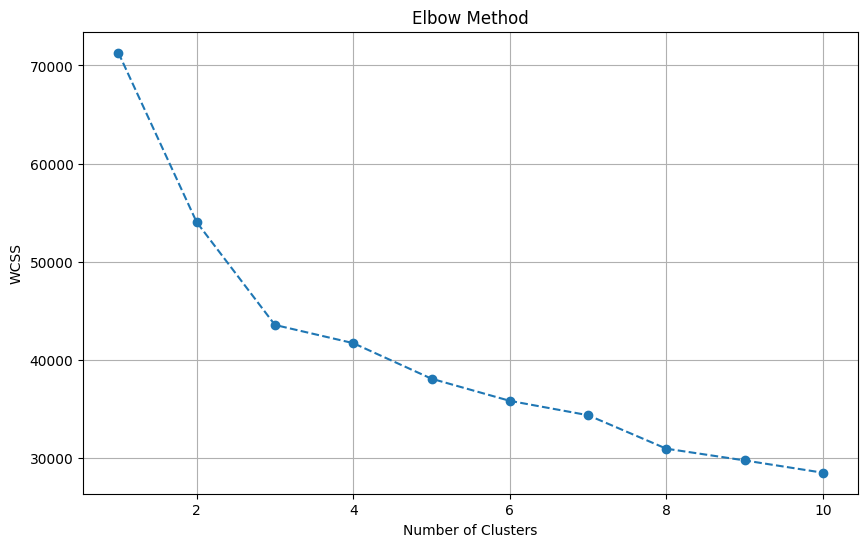

In [206]:
# plotting the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [207]:
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
clusters_assignment = kmeans.fit_predict(scaled_data)

In [208]:
# 0--> Unfurnished, 1--> Semi-furnished, 2--> Furnished
df['furnishign_type'] = clusters_assignment
df[['furnishign_type']].value_counts()

furnishign_type
2                  2635
0                  1106
1                   220
Name: count, dtype: int64

In [209]:
df.sample(5)

,Unnamed: 0,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,...,Modular Kitchen,Wardrobe,Exhaust Fan,Light,Water Purifier,Geyser,Dining Table,Bed,Curtains,furnishign_type
1930,1930,flat,awho sispal vihar,sector 49,2.00,7262.0,2754.0,Super Built up area 2754(255.85 sq.m.),4,3,...,0,0,0,4,0,2,0,0,0,2
1793,1793,flat,tulip violet,sector 69,1.70,8445.0,2013.0,Super Built up area 2010(186.74 sq.m.),4,4,...,1,0,0,0,0,0,0,0,0,2
2586,2586,flat,samaspurkunj,sector 59,0.55,5238.0,1050.0,Carpet area: 1050 (97.55 sq.m.),2,2,...,0,3,0,5,0,2,0,2,0,2
3341,3341,house,NaN,sector 3,0.68,3874.0,1755.0,Built Up area: 1755 (163.04 sq.m.),5,3,...,0,0,0,1,0,0,0,0,0,2
806,806,flat,pareena coban residences,sector 99a,1.08,6625.0,1630.0,Super Built up area 1997(185.53 sq.m.)Built Up...,3,5,...,1,0,0,0,0,0,0,0,0,2


## Feature Column

In [210]:
# Working with the features column to extract the features and create a scale of luxury for the properties based on the features.
df.features.isnull().sum()

np.int64(709)

In [230]:
df['society'] = df['society'].str.lower()

In [231]:
# Loading the appartment dataset
app_path = Project_root / "Data" / "Raw" / "appartments.csv"
app_df = pd.read_csv(app_path)
app_df.head()

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Pa...","{'Bajghera Road': '800 Meter', 'Palam Vihar Ha...",https://www.99acres.com/smartworld-one-dxp-sec...,"{'2 BHK': {'building_type': 'Apartment', 'area...","['Swimming Pool', 'Salon', 'Restaurant', 'Spa'..."
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap Un...","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The N...",https://www.99acres.com/m3m-crown-sector-111-g...,"{'3 BHK': {'building_type': 'Apartment', 'area...","['Bowling Alley', 'Mini Theatre', 'Manicured G..."
2,Adani Brahma Samsara Vilasa,"Land, 3, 4 BHK Independent Floor in Sector 63,...","['AIPL Business Club Sector 62', 'Heritage Xpe...","{'AIPL Business Club Sector 62': '2.7 Km', 'He...",https://www.99acres.com/adani-brahma-samsara-v...,{'3 BHK': {'building_type': 'Independent Floor...,"['Terrace Garden', 'Gazebo', 'Fountain', 'Amph..."
3,Sobha City,"2, 3, 4 BHK Apartment in Sector 108, Gurgaon","['The Shikshiyan School', 'WTC Plaza', 'Luxus ...","{'The Shikshiyan School': '2.9 KM', 'WTC Plaza...",https://www.99acres.com/sobha-city-sector-108-...,"{'2 BHK': {'building_type': 'Apartment', 'area...","['Swimming Pool', 'Volley Ball Court', 'Aerobi..."
4,Signature Global City 93,"2, 3 BHK Independent Floor in Sector 93 Gurgaon","['Pranavananda Int. School', 'DLF Site central...","{'Pranavananda Int. School': '450 m', 'DLF Sit...",https://www.99acres.com/signature-global-city-...,{'2 BHK': {'building_type': 'Independent Floor...,"['Mini Theatre', 'Doctor on Call', 'Concierge ..."


In [238]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [253]:
temp_df = df[df['features'].isnull()]

In [254]:
x = temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']


In [255]:
df['features'].isnull().sum()

np.int64(709)

In [256]:

from sklearn.preprocessing import MultiLabelBinarizer
import ast

# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [216]:

df['features'].isnull().sum()

np.int64(709)

In [262]:
features_binary_df.shape

(3961, 32)

In [259]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[[col for col in weights.keys() if col in features_binary_df.columns]].mul([weights[col] for col in weights.keys() if col in features_binary_df.columns]).sum(axis=1)

In [260]:
df['luxury_score'] = luxury_score

In [261]:
df.head()

,Unnamed: 0,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,...,Exhaust Fan,Light,Water Purifier,Geyser,Dining Table,Bed,Curtains,furnishign_type,features_list,luxury_score
0,0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,...,0,4,0,0,0,0,0,2,"[Feng Shui / Vaastu Compliant, Security / Fire...",28
1,1,flat,apna enclave,sector 5,0.50,7692.0,650.0,Carpet area: 650 (60.39 sq.m.),2,2,...,1,3,0,1,0,0,1,0,"[Security / Fire Alarm, Maintenance Staff, Wat...",37
2,2,flat,tulsiani easy in homes,sector 48,0.40,6722.0,595.0,Carpet area: 595 (55.28 sq.m.),2,2,...,0,0,0,0,0,0,0,2,"[Power Back-up, Feng Shui / Vaastu Compliant, ...",36
3,3,flat,smart world orchard,sector 61,1.47,12250.0,1200.0,Carpet area: 1200 (111.48 sq.m.),2,2,...,0,0,0,0,0,0,0,2,"[Security / Fire Alarm, Private Garden / Terra...",76
4,4,flat,parkwood westend,sector 92,0.70,5204.0,1345.0,Super Built up area 1345(124.95 sq.m.),2,2,...,0,0,0,0,0,0,0,2,[],0
